# 🏛️ RenAIssance OCR Pipeline
### Tesseract 5 · Layout-Aware · 280+ Normalization Rules
### HumanAI — GSoC 2026 Technical Submission

---

## ▶ How to Run This Notebook

> **No setup required. No file uploads. No Google Drive needed.**

1. Open this notebook in [Google Colab](https://colab.research.google.com)
2. In the menu: **Runtime → Run All** (or press `Ctrl+F9`)
3. The notebook will automatically:
   - Install all dependencies
   - **Download the dataset** from the project's public Google Drive folder
   - Run the full OCR pipeline on all PDF documents
   - Evaluate results against ground-truth transcriptions
   - Save all outputs to `/content/output/`
4. Total runtime: approximately **10–15 minutes** on a Tesla T4 GPU

All results are saved under `/content/output/` inside the Colab runtime.

---

## Pipeline Overview

```
┌─────────────────────────────────────────────────────────────┐
│  DATASET (auto-downloaded from Google Drive)                │
│  PDF scans + ground-truth DOCX transcriptions               │
└────────────────────────┬────────────────────────────────────┘
                         │
            ┌────────────▼────────────┐
            │  Page Extraction        │  pdf2image · adaptive DPI
            └────────────┬────────────┘
                         │
            ┌────────────▼────────────┐
            │  Image Preprocessing    │  grayscale · margin crop
            │                         │  deskew (3-method cascade)
            │                         │  layout detection · col split
            │                         │  binarization (Otsu/Adaptive)
            └────────────┬────────────┘
                         │
            ┌────────────▼────────────┐
            │  Tesseract 5 OCR        │  LSTM · Spanish · --oem 1
            └────────────┬────────────┘
                         │
            ┌────────────▼────────────┐
            │  Text Normalization     │  280+ rules · long-s · ligatures
            │                         │  hyphenation merge · garbage strip
            └────────────┬────────────┘
                         │
            ┌────────────▼────────────┐
            │  Evaluation             │  CER · CER* · WER · Accuracy*
            └────────────┬────────────┘
                         │
            ┌────────────▼────────────┐
            │  /content/output/       │  .txt · .json · charts
            └─────────────────────────┘
```

---

| Section | Purpose |
|---------|------------------------------------------------------------|
| **1** | Install system + Python dependencies |
| **2** | Download dataset (PDFs + ground-truth DOCX) |
| **3** | Configuration — all paths inside `/content/` |
| **4** | Ground-truth parsing (DOCX → dict) |
| **5** | Image preprocessing utilities |
| **6** | OCR engine (Tesseract wrapper) |
| **7** | Post-processing & normalization (280+ rules) |
| **8** | Main pipeline — process all PDFs |
| **9** | Page visualization (original · preprocessed · OCR text) |
| **10** | Evaluation — CER / WER per page + averages |
| **11** | OCR error analysis (long-s, ligatures, noise) |
| **12** | Results summary & future work |

## 1 · Install Dependencies

Installs Tesseract 5 (with Spanish language pack), `pdf2image`, `jiwer`, and all
other required libraries. Also installs `gdown` for dataset download.

In [1]:
%%bash
set -e

echo '── System packages ──────────────────────────────────────────'
apt-get install -y -qq \
    tesseract-ocr \
    tesseract-ocr-spa \
    poppler-utils \
    libgl1 \
    libglib2.0-0

echo '── Python packages ──────────────────────────────────────────'
pip install -q \
    gdown \
    pdf2image \
    pytesseract \
    opencv-python-headless \
    Pillow \
    scipy \
    numpy \
    pandas \
    tqdm \
    'jiwer>=3.0' \
    python-docx \
    matplotlib \
    editdistance

echo '── Verify Tesseract ─────────────────────────────────────────'
python3 - <<'EOF'
import pytesseract
v     = pytesseract.get_tesseract_version()
langs = pytesseract.get_languages()
assert 'spa' in langs, 'Spanish language pack not found!'
print(f'Tesseract {v}')
print(f'Languages : {langs}')
print('✓ Spanish pack confirmed')
EOF

echo '✓ All dependencies ready'

── System packages ──────────────────────────────────────────
Selecting previously unselected package poppler-utils.
(Reading database ... 121852 files and directories currently installed.)
Preparing to unpack .../poppler-utils_22.02.0-2ubuntu0.12_amd64.deb ...
Unpacking poppler-utils (22.02.0-2ubuntu0.12) ...
Selecting previously unselected package tesseract-ocr-spa.
Preparing to unpack .../tesseract-ocr-spa_1%3a4.00~git30-7274cfa-1.1_all.deb ...
Unpacking tesseract-ocr-spa (1:4.00~git30-7274cfa-1.1) ...
Setting up tesseract-ocr-spa (1:4.00~git30-7274cfa-1.1) ...
Setting up poppler-utils (22.02.0-2ubuntu0.12) ...
Processing triggers for man-db (2.10.2-1) ...
── Python packages ──────────────────────────────────────────
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 85.0 MB/s eta 0:00:00
── Verify Tesseract ─────────────────────────────────────────
Tesseract 4.1.1
Languages : ['eng', 'osd', 'spa']


## 2 · Download Dataset

Downloads both ZIP files (PDFs and transcripts) from the project's public
Google Drive folder and extracts them into `/content/data/`.

```
/content/data/
    pdf/          ← PDF scan files
    transcripts/  ← ground-truth DOCX transcriptions
```

No authentication required — the folder is publicly shared.

In [2]:
import os
import zipfile
import shutil
from pathlib import Path
import gdown

# ── Dataset source ─────────────────────────────────────────────────────────
FOLDER_ID   = '1eBYVaxBzp27k2Vgh4u5HYaVIwnn3H9z2'
FOLDER_URL  = f'https://drive.google.com/drive/folders/{FOLDER_ID}'

# ── Local paths ────────────────────────────────────────────────────────────
DATA_ROOT   = Path('/content/data')
PDF_DIR     = DATA_ROOT / 'pdf'
TRANS_DIR   = DATA_ROOT / 'transcripts'
ZIPS_DIR    = DATA_ROOT / '_zips'

for d in [PDF_DIR, TRANS_DIR, ZIPS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Download entire folder ─────────────────────────────────────────────────
print(f'Downloading from: {FOLDER_URL}')
print('This may take ~1 minute on first run...')

downloaded = gdown.download_folder(
    id=FOLDER_ID,
    output=str(ZIPS_DIR),
    quiet=False,
    use_cookies=False,
)

print(f'\nFiles downloaded: {downloaded}')

# ── Extract ZIPs into correct subdirectories ───────────────────────────────
def extract_zip(zip_path: Path, dest: Path):
    """Extract a ZIP file, flattening any single top-level directory."""
    with zipfile.ZipFile(zip_path, 'r') as z:
        members = z.namelist()
        # Detect common prefix to strip
        prefix = ''
        if all(m.startswith(members[0].split('/')[0] + '/') for m in members if '/' in m):
            prefix = members[0].split('/')[0] + '/'
        for member in members:
            target_name = member[len(prefix):] if member.startswith(prefix) else member
            if not target_name:          # skip directory entries
                continue
            target_path = dest / target_name
            target_path.parent.mkdir(parents=True, exist_ok=True)
            if not member.endswith('/'):
                with z.open(member) as src, open(target_path, 'wb') as dst:
                    shutil.copyfileobj(src, dst)

zip_files = list(ZIPS_DIR.rglob('*.zip'))
print(f'\nFound {len(zip_files)} ZIP file(s): {[z.name for z in zip_files]}')

for zf in zip_files:
    name_lower = zf.name.lower()
    # Route by filename hints
    if any(k in name_lower for k in ('pdf', 'scan', 'document')):
        dest = PDF_DIR
    elif any(k in name_lower for k in ('transcript', 'gt', 'ground', 'docx', 'test')):
        dest = TRANS_DIR
    else:
        # Inspect contents to decide
        with zipfile.ZipFile(zf) as z:
            names = z.namelist()
        has_pdf  = any(n.lower().endswith('.pdf')  for n in names)
        has_docx = any(n.lower().endswith('.docx') for n in names)
        dest = PDF_DIR if has_pdf else TRANS_DIR
    print(f'  Extracting {zf.name} → {dest} ...')
    extract_zip(zf, dest)

# ── If folder contained loose files (no ZIPs), route them directly ─────────
if not zip_files:
    print('No ZIPs found — routing loose files...')
    for f in ZIPS_DIR.rglob('*'):
        if f.is_file():
            if f.suffix.lower() == '.pdf':
                shutil.copy2(f, PDF_DIR / f.name)
            elif f.suffix.lower() == '.docx':
                shutil.copy2(f, TRANS_DIR / f.name)

# ── Report ─────────────────────────────────────────────────────────────────
pdfs   = sorted(PDF_DIR.rglob('*.pdf'))
docxes = sorted(TRANS_DIR.rglob('*.docx'))

print('\n' + '='*55)
print('  Dataset ready')
print('='*55)
print(f'  PDFs       : {len(pdfs)}')
for p in pdfs:
    print(f'    • {p.name}')
print(f'  Transcripts: {len(docxes)}')
for d in docxes:
    print(f'    • {d.name}')

if not pdfs:
    raise RuntimeError(
        'No PDFs found after extraction. '
        'Check that the Google Drive folder is publicly accessible '
        f'and contains PDF files. Folder: {FOLDER_URL}'
    )

This may take ~1 minute on first run...


Retrieving folder contents


Processing file 1jdAX0v1rVfnlGUJwTQH8NVHlJVPcaxqB pdf_scan.zip
Processing file 1CNMzc7laDH1pGDtBpDZ2pam63XCjnhOr transcription.zip


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1jdAX0v1rVfnlGUJwTQH8NVHlJVPcaxqB
From (redirected): https://drive.google.com/uc?id=1jdAX0v1rVfnlGUJwTQH8NVHlJVPcaxqB&confirm=t&uuid=65c2f140-6658-4ac5-a9ff-03a6fea02e3e
To: /content/data/_zips/pdf_scan.zip
100%|██████████| 30.9M/30.9M [00:00<00:00, 33.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1CNMzc7laDH1pGDtBpDZ2pam63XCjnhOr
To: /content/data/_zips/transcription.zip
100%|██████████| 127k/127k [00:00<00:00, 46.8MB/s]


Files downloaded: ['/content/data/_zips/pdf_scan.zip', '/content/data/_zips/transcription.zip']

Found 2 ZIP file(s): ['transcription.zip', 'pdf_scan.zip']
  Extracting transcription.zip → /content/data/transcripts ...
  Extracting pdf_scan.zip → /content/data/pdf ...

  Dataset ready
  PDFs       : 6
    • Buendia - Instruccion.pdf
    • Covarrubias - Tesoro lengua.pdf
    • Guardiola - Tratado nobleza.pdf
    • PORCONES.228.38 – 1646.pdf
    • PORCONES.23.5 - 1628.pdf
    • PORCONES.748.6 – 1650.pdf
  Transcripts: 6
    • Buendia - Instruccion transcription.docx
    • Covarrubias - Tesoro lengua transcription.docx
    • Guardiola - Tratado nobleza transcription.docx
    • PORCONES.228.38 - 1646 transcription.docx
    • PORCONES.23.5 - 1628 transcription.docx
    • PORCONES.748.6 – 1650 Transcription.docx



Download completed


## 3 · Configuration

All paths point to `/content/` — no Google Drive, no manual edits needed.

| Variable | Value | Description |
|----------|-------|-------------|
| `PDF_DIR` | `/content/data/pdf` | Input PDFs (populated by §2) |
| `TRANS_DIR` | `/content/data/transcripts` | Ground-truth DOCX files |
| `OUTPUT_DIR` | `/content/output` | All OCR outputs |
| `TESS_LANG` | `spa` | Tesseract language |
| `DEFAULT_DPI` | `250` | Rendering DPI (auto-reduced for high-res) |
| `TARGET_WIDTH` | `1400` | Pixel width fed to Tesseract |
| `BINARIZATION` | `otsu` | `otsu` or `adaptive` |

In [3]:
import warnings
import re
import json
import time
import collections
import unicodedata
from pathlib import Path
from typing import Dict, List, Optional, Tuple

warnings.filterwarnings('ignore')

# ── Paths (all inside /content — no Drive required) ────────────────────────
PDF_DIR    = Path('/content/data/pdf')
TRANS_DIR  = Path('/content/data/transcripts')
OUTPUT_DIR = Path('/content/output')

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── OCR settings ───────────────────────────────────────────────────────────
TESS_LANG    = 'spa'    # Tesseract language code
DEFAULT_DPI  = 250      # rendering DPI (auto-reduced for already high-res scans)
DEFAULT_PSM  = 6        # 6 = uniform text block; 4 = single column variable sizes
TARGET_WIDTH = 1400     # px width fed to Tesseract after resize
BINARIZATION = 'otsu'   # 'otsu' | 'adaptive'

# ── Discover files ─────────────────────────────────────────────────────────
pdf_files = sorted(PDF_DIR.rglob('*.pdf'))
docx_files = sorted(TRANS_DIR.rglob('*.docx'))

print('Configuration')
print('='*55)
print(f'  PDF_DIR    : {PDF_DIR}')
print(f'  TRANS_DIR  : {TRANS_DIR}')
print(f'  OUTPUT_DIR : {OUTPUT_DIR}')
print(f'  TESS_LANG  : {TESS_LANG}')
print(f'  DPI        : {DEFAULT_DPI}')
print(f'  PSM        : {DEFAULT_PSM}')
print(f'  Binarize   : {BINARIZATION}')
print(f'  Target W   : {TARGET_WIDTH}px')
print()
print(f'  PDFs found       : {len(pdf_files)}')
for p in pdf_files:
    print(f'    • {p.name}')
print(f'  Transcripts found: {len(docx_files)}')
for d in docx_files:
    print(f'    • {d.name}')

assert pdf_files, f'No PDFs in {PDF_DIR} — re-run §2'

Configuration
  PDF_DIR    : /content/data/pdf
  TRANS_DIR  : /content/data/transcripts
  OUTPUT_DIR : /content/output
  TESS_LANG  : spa
  DPI        : 250
  PSM        : 6
  Binarize   : otsu
  Target W   : 1400px

  PDFs found       : 6
    • Buendia - Instruccion.pdf
    • Covarrubias - Tesoro lengua.pdf
    • Guardiola - Tratado nobleza.pdf
    • PORCONES.228.38 – 1646.pdf
    • PORCONES.23.5 - 1628.pdf
    • PORCONES.748.6 – 1650.pdf
  Transcripts found: 6
    • Buendia - Instruccion transcription.docx
    • Covarrubias - Tesoro lengua transcription.docx
    • Guardiola - Tratado nobleza transcription.docx
    • PORCONES.228.38 - 1646 transcription.docx
    • PORCONES.23.5 - 1628 transcription.docx
    • PORCONES.748.6 – 1650 Transcription.docx


## 4 · Ground-Truth Parsing

Each DOCX transcript uses paragraph markers of the form **`PDF pN`** to delimit
pages.  This cell parses every DOCX in `TRANS_DIR` and builds a lookup table
`GT_BY_PDF` keyed by `(pdf_stem, 0-based-page-index)`.

**Example DOCX structure:**
```
PDF p2
Al INFINITAMENTE AMABLE NIÑO JESUS...

PDF p3
guro disseño de su edad: la Religion...
```

In [4]:
import docx as _docx

_PAGE_MARKER = re.compile(r'^PDF\s+p(\d+)', re.IGNORECASE)

def _clean_gt_text(text: str) -> str:
    text = re.sub(r'-\s*\n\s*', '', text)   # merge hyphenated line-breaks
    text = text.replace('\n', ' ')
    text = re.sub(r'\s{2,}', ' ', text)
    return text.strip()


def parse_docx(docx_path: Path) -> Dict[int, str]:
    """
    Parse one ground-truth DOCX.
    Returns {0-based page index: cleaned text}.
    """
    doc = _docx.Document(str(docx_path))
    gt, cur_pg, buf = {}, None, []

    def _flush():
        if cur_pg is not None and buf:
            gt[cur_pg - 1] = _clean_gt_text(' '.join(buf))

    for para in doc.paragraphs:
        txt = para.text.strip()
        if not txt or txt.upper().startswith('NOTES'):
            continue
        m = _PAGE_MARKER.match(txt)
        if m:
            _flush()
            cur_pg, buf = int(m.group(1)), []
        else:
            buf.append(txt)
    _flush()
    return gt


def _stem_key(name: str) -> str:
    """Normalised stem for fuzzy PDF↔DOCX matching (lower, no spaces)."""
    return re.sub(r'[\s_-]+', '', name.lower())


def match_transcript(pdf_path: Path, docx_files: List[Path]) -> Optional[Path]:
    """
    Find the best-matching DOCX for a PDF by longest common stem substring.
    Returns None if no DOCX files are available.
    """
    if not docx_files:
        return None
    pdf_key = _stem_key(pdf_path.stem)
    best, best_score = None, 0
    for d in docx_files:
        doc_key = _stem_key(d.stem)
        # Score = length of overlap in the shorter of the two keys
        overlap = sum(1 for a, b in zip(pdf_key, doc_key) if a == b)
        # Prefer containing-substring match
        if pdf_key[:10] in doc_key or doc_key[:10] in pdf_key:
            overlap += 20
        if overlap > best_score:
            best, best_score = d, overlap
    return best


# ── Build global GT lookup: {(pdf_stem, pg_0based): gt_text} ──────────────
GT: Dict[Tuple[str, int], str] = {}
GT_BY_PDF: Dict[str, Dict[int, str]] = {}   # pdf_stem → {pg: text}

for pdf_path in pdf_files:
    transcript = match_transcript(pdf_path, docx_files)
    if transcript is None:
        print(f'  {pdf_path.name}: no transcript found')
        continue
    gt_pages = parse_docx(transcript)
    GT_BY_PDF[pdf_path.stem] = gt_pages
    for pg_idx, text in gt_pages.items():
        GT[(pdf_path.stem, pg_idx)] = text
    print(f'  {pdf_path.name} ↔ {transcript.name} ({len(gt_pages)} GT pages)')

print(f'\n✓ Total ground-truth entries: {len(GT)}')

  Buendia - Instruccion.pdf ↔ Buendia - Instruccion transcription.docx (3 GT pages)
  Covarrubias - Tesoro lengua.pdf ↔ Covarrubias - Tesoro lengua transcription.docx (3 GT pages)
  Guardiola - Tratado nobleza.pdf ↔ Guardiola - Tratado nobleza transcription.docx (3 GT pages)
  PORCONES.228.38 – 1646.pdf ↔ PORCONES.228.38 - 1646 transcription.docx (5 GT pages)
  PORCONES.23.5 - 1628.pdf ↔ PORCONES.23.5 - 1628 transcription.docx (4 GT pages)
  PORCONES.748.6 – 1650.pdf ↔ PORCONES.748.6 – 1650 Transcription.docx (4 GT pages)

✓ Total ground-truth entries: 22


## 5 · Image Preprocessing Utilities

| Function | What it does |
|----------|--------------|
| `binarize` | Otsu or adaptive thresholding |
| `resize_for_tesseract` | Scale to `TARGET_WIDTH`, cap height at 9000 px |
| `pad_image` | White border — prevents Tesseract edge mis-reads |
| `deskew` | 3-method cascade: HoughLinesP → minAreaRect → projection profile |
| `crop_text_region` | Remove large white margins |
| `detect_layout` | Single-column vs two-column via ink-density projection |
| `split_columns` | Split two-column page at the detected ink gap |

In [5]:
import cv2
import numpy as np
from scipy import ndimage


# ── Binarization ───────────────────────────────────────────────────────────

def binarize(gray: np.ndarray, method: str = 'otsu') -> np.ndarray:
    """Grayscale → binary.  method: 'otsu' | 'adaptive'."""
    if method == 'adaptive':
        block = max(11, (min(gray.shape) // 25) | 1)
        return cv2.adaptiveThreshold(
            gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY, block, 10)
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
    return binary


# ── Resize & pad ───────────────────────────────────────────────────────────

_TARGET_H_MAX = 9000
_PADDING_PX   = 30

def resize_for_tesseract(img: np.ndarray, target_w: int = TARGET_WIDTH) -> np.ndarray:
    h, w = img.shape[:2]
    if w != target_w:
        new_h  = int(h * target_w / w)
        interp = cv2.INTER_AREA if target_w < w else cv2.INTER_LINEAR
        img    = cv2.resize(img, (target_w, new_h), interpolation=interp)
    if img.shape[0] > _TARGET_H_MAX:
        new_w = int(img.shape[1] * _TARGET_H_MAX / img.shape[0])
        img   = cv2.resize(img, (new_w, _TARGET_H_MAX), interpolation=cv2.INTER_AREA)
    return img

def pad_image(img: np.ndarray, px: int = _PADDING_PX) -> np.ndarray:
    return cv2.copyMakeBorder(img, px, px, px, px, cv2.BORDER_CONSTANT, value=255)


# ── Deskew — 3-method cascade ──────────────────────────────────────────────

_MAX_SKEW = 8.0

def _rotate(img: np.ndarray, angle: float) -> np.ndarray:
    if abs(angle) < 0.05:
        return img
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h),
                          flags=cv2.INTER_LINEAR,
                          borderMode=cv2.BORDER_CONSTANT, borderValue=255)

def _angle_hough(binary: np.ndarray) -> Optional[float]:
    edges = cv2.Canny(binary, 50, 150, apertureSize=3)
    lines = cv2.HoughLinesP(edges, 1, np.pi / 180, 80,
                             minLineLength=binary.shape[1] // 4, maxLineGap=20)
    if lines is None:
        return None
    angles = [np.degrees(np.arctan2(y2 - y1, x2 - x1))
               for x1, y1, x2, y2 in lines[:, 0] if abs(x2 - x1) > 10]
    angles = [a for a in angles if abs(a) < _MAX_SKEW]
    return float(np.median(angles)) if len(angles) >= 5 else None

def _angle_minarearect(binary: np.ndarray) -> Optional[float]:
    inv = cv2.bitwise_not(binary)
    contours, _ = cv2.findContours(inv, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    pts = np.vstack(contours).squeeze()
    if len(pts) < 50:
        return None
    angle = cv2.minAreaRect(pts)[2]
    if angle < -45:
        angle += 90
    return float(angle) if abs(angle) < _MAX_SKEW else None

def _angle_projection(binary: np.ndarray) -> float:
    inv  = cv2.bitwise_not(binary).astype(np.float32)
    best_angle, best_var = 0.0, -1.0
    for angle in np.linspace(-_MAX_SKEW, _MAX_SKEW, 41):
        var = float(np.var(_rotate(inv, angle).sum(axis=1)))
        if var > best_var:
            best_var, best_angle = var, angle
    return best_angle

def deskew(img: np.ndarray) -> np.ndarray:
    """Auto-correct skew ≤ ±8°.  Cascade: Hough → minAreaRect → projection."""
    assert img.ndim == 2
    _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
    angle = _angle_hough(binary) or _angle_minarearect(binary) or _angle_projection(binary)
    return _rotate(img, -angle) if abs(angle) > 0.1 else img


# ── Margin crop ────────────────────────────────────────────────────────────

def crop_text_region(gray: np.ndarray, margin_frac: float = 0.02) -> np.ndarray:
    """Crop to bounding box of text content, trimming excess white margins."""
    _, bw   = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)
    k       = cv2.getStructuringElement(cv2.MORPH_RECT, (20, 4))
    dilated = cv2.dilate(bw, k, iterations=3)
    coords  = cv2.findNonZero(dilated)
    if coords is None:
        return gray
    x, y, w, h = cv2.boundingRect(coords)
    mw = int(gray.shape[1] * margin_frac)
    mh = int(gray.shape[0] * margin_frac)
    return gray[max(0, y - mh) : min(gray.shape[0], y + h + mh),
                max(0, x - mw) : min(gray.shape[1], x + w + mw)]


# ── Layout detection ────────────────────────────────────────────────────────

def detect_layout(gray: np.ndarray, downsample_w: int = 1500) -> str:
    """
    Classify page as 'single_column' or 'two_column' via vertical
    ink-density profile and whitespace gap analysis.
    """
    h, w  = gray.shape
    scale = w / min(w, downsample_w)
    proc  = cv2.resize(gray,
                       (min(w, downsample_w), max(1, int(h / scale))),
                       interpolation=cv2.INTER_AREA)
    _, bw = cv2.threshold(proc, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)
    bw    = cv2.dilate(bw, cv2.getStructuringElement(cv2.MORPH_RECT, (5, 1)), iterations=2)
    dens  = bw.sum(axis=0) / (255.0 * proc.shape[0])
    sm    = ndimage.gaussian_filter1d(dens, sigma=max(8, int(proc.shape[1] * 0.015)))

    thr       = sm.max() * 0.10
    min_gap_w = int(len(sm) * 0.012)
    is_gap    = sm <= thr
    gaps, in_gap, g0 = [], False, 0
    for i, g in enumerate(is_gap):
        if g and not in_gap:
            g0, in_gap = i, True
        elif not g and in_gap:
            if i - g0 >= min_gap_w:
                gaps.append((g0, i))
            in_gap = False

    lo, hi = int(len(sm) * 0.20), int(len(sm) * 0.80)
    central = [g for g in gaps
                if lo < (g[0] + g[1]) // 2 < hi
                and (g[1] - g[0]) >= int(len(sm) * 0.04)]
    return 'two_column' if central else 'single_column'


# ── Column splitting ────────────────────────────────────────────────────────

def split_columns(gray: np.ndarray, padding: int = 15) -> List[np.ndarray]:
    """Split a two-column page at the detected centre gap."""
    if detect_layout(gray) == 'single_column':
        return [gray]

    h, w   = gray.shape
    proc_w = min(w, 1500)
    scale  = w / proc_w
    proc   = cv2.resize(gray, (proc_w, max(1, int(h / scale))),
                        interpolation=cv2.INTER_AREA)
    _, bw  = cv2.threshold(proc, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)
    bw     = cv2.dilate(bw, cv2.getStructuringElement(cv2.MORPH_RECT, (5, 1)), iterations=2)
    dens   = bw.sum(axis=0) / (255.0 * proc.shape[0])
    sm     = ndimage.gaussian_filter1d(dens, sigma=max(8, int(proc_w * 0.015)))

    thr    = sm.max() * 0.10
    active = sm > thr
    runs, in_run, s0 = [], False, 0
    for i, a in enumerate(active):
        if a and not in_run:
            s0, in_run = i, True
        elif not a and in_run:
            if (i - s0) >= int(proc_w * 0.10):
                runs.append((s0, i))
            in_run = False

    if len(runs) < 2:
        return [gray]

    gap_sl  = sm[runs[0][1] : runs[1][0]]
    min_pos = runs[0][1] + (int(np.argmin(gap_sl)) if len(gap_sl) else 0)
    split_x = max(w // 6, min(int(min_pos * scale), 5 * w // 6))

    white = np.full((h, padding), 255, dtype=np.uint8)
    return [
        np.hstack([gray[:, :split_x],  white]),
        np.hstack([white, gray[:, split_x:]]),
    ]


print('✓ Preprocessing utilities loaded')

✓ Preprocessing utilities loaded


## 6 · OCR Engine

Wraps Tesseract 5 (`--oem 1` = LSTM only, `--psm 6` = uniform text block).

- **`ocr_column`** — Tesseract on a single binarized column image
- **`ocr_page`** — full page pipeline: crop → deskew → layout → split → OCR

In [6]:
import pytesseract
from PIL import Image as PILImage
from pdf2image import convert_from_path


def load_pdf_pages(pdf_path: Path, dpi: int = DEFAULT_DPI) -> List[np.ndarray]:
    """
    Render PDF to grayscale numpy arrays.
    Probes first page at 72 DPI to avoid redundant upscaling of
    already high-resolution embedded scans.
    """
    probe      = convert_from_path(str(pdf_path), dpi=72, last_page=1)
    _, pw      = np.array(probe[0]).shape[:2]
    actual_dpi = 72 if pw > 2000 else dpi

    pages_pil = convert_from_path(str(pdf_path), dpi=actual_dpi)
    grays     = []
    for pg in pages_pil:
        arr  = np.array(pg)
        gray = cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY) if arr.ndim == 3 else arr
        grays.append(gray)
    del pages_pil
    return grays


def ocr_column(img: np.ndarray,
               psm: int           = DEFAULT_PSM,
               binarization: str  = BINARIZATION,
               target_w: int      = TARGET_WIDTH) -> str:
    """Run Tesseract on one column/region."""
    assert img.ndim == 2, 'Expected grayscale'
    binary  = binarize(img, method=binarization)
    padded  = pad_image(binary)
    resized = resize_for_tesseract(padded, target_w)
    cfg     = f'--psm {psm} --oem 1 -l {TESS_LANG}'
    return pytesseract.image_to_string(
        PILImage.fromarray(resized), config=cfg
    ).replace('\f', '').strip()


def ocr_page(gray: np.ndarray,
              psm: int           = DEFAULT_PSM,
              binarization: str  = BINARIZATION,
              target_w: int      = TARGET_WIDTH,
              do_deskew: bool    = True,
              col_shrink_px: int = 0,
              is_spread: bool    = False) -> Tuple[str, str]:
    """
    Full per-page OCR pipeline.  Returns (raw_text, layout_str).

    Steps:
      1. Crop two-page spread to right half  (if is_spread)
      2. Crop white margins
      3. Deskew
      4. Detect layout (single / two-column)
      5. Split columns
      6. OCR each column  →  join with newline
    """
    if is_spread:
        gray = gray[:, gray.shape[1] // 2:]

    gray   = crop_text_region(gray)
    layout = detect_layout(gray)

    if do_deskew:
        gray = deskew(gray)

    columns = split_columns(gray)

    if do_deskew and len(columns) > 1:
        columns = [deskew(c) for c in columns]

    if col_shrink_px > 0:
        columns = [
            c[:, col_shrink_px : c.shape[1] - col_shrink_px]
            if c.shape[1] > col_shrink_px * 2 else c
            for c in columns
        ]

    texts = []
    for col in columns:
        if col.size == 0:
            continue
        t = ocr_column(col, psm=psm, binarization=binarization, target_w=target_w)
        if t.strip():
            texts.append(t)

    return '\n'.join(texts), layout


print('✓ OCR engine loaded')

✓ OCR engine loaded


## 7 · Text Normalization (280+ Rules)

Rule-based post-processing pipeline tailored for 18th-century Spanish printing.

| Stage | What it corrects |
|-------|------------------|
| Base clean | Noise symbols (`|`, `§`, `†`, …), curly quotes, whitespace |
| Hyphenation | `nues-⏎tra` → `nuestra` |
| Long-s | `ſ / f / í / l → s` (e.g. `fe→se`, `vueftra→vuestra`) |
| OCR confusion | `vn→un`, `vna→una`, `q→que`, leading `0→o`, word fusions |
| Garbage prefix | Strips leading junk from decorative woodcut initials |

In [7]:
def _apply_rules(text: str, rules: list) -> str:
    for pat, rep in rules:
        try:
            text = re.sub(pat, rep, text)
        except re.error:
            pass
    return text


def _base_clean(text: str) -> str:
    text = re.sub(r'-\s*\n\s*', '', text)                # hyphenation
    text = text.replace('\n', ' ')
    text = text.replace('ſ', 's').replace('\u00cd', 's') # Unicode long-s
    text = re.sub(r'[|=*§¶†‡«»\[\]]{1,}', ' ', text)
    text = re.sub(r'["""]', '"', text)
    text = re.sub(r"[''']", "'", text)
    text = re.sub(r'[+~^_\\»¿¡]{1,}', ' ', text)
    text = re.sub(r'(?<!\w)[\/\\@#%]{1,}(?!\w)', ' ', text)
    text = re.sub(r'\s{2,}', ' ', text).strip()
    return text


_LONG_S_RULES = [
    (r'\bfe\b','se'),    (r'\bfi\b','si'),    (r'\bfu\b','su'),
    (r'\bfus\b','sus'),  (r'\bfon\b','son'),  (r'\bfer\b','ser'),
    (r'\bfea\b','sea'),  (r'\bfin\b','sin'),  (r'\bfino\b','sino'),
    (r'\bfolo\b','solo'),(r'\bfola\b','sola'),(r'\bfan\b','san'),
    (r'\befte\b','este'), (r'\befta\b','esta'), (r'\befto\b','esto'),
    (r'\beftos\b','estos'),(r'\beftas\b','estas'),
    (r'\bvueftra\b','vuestra'),(r'\bvueftro\b','vuestro'),
    (r'\bnueftra\b','nuestra'),(r'\bnueftro\b','nuestro'),
    (r'\bfiempre\b','siempre'),(r'\bfaber\b','saber'),(r'\bfobre\b','sobre'),
    (r'\bfagrado\b','sagrado'),(r'\bfanto\b','santo'),(r'\bfanta\b','santa'),
    (r'\bcofas\b','cosas'),   (r'\bcofa\b','cosa'),
    (r'\bperfona\b','persona'),(r'\bprefente\b','presente'),
    (r'\bdefde\b','desde'),   (r'\bdefpues\b','despues'),
    (r'\beftar\b','estar'),   (r'\beftando\b','estando'),
    (r'\befcribir\b','escribir'),(r'\befcapar\b','escapar'),
    (r'\bpuefto\b','puesto'), (r'\bcaufa\b','causa'),(r'\bcaufas\b','causas'),
    (r'\bteftigo\b','testigo'),(r'\binftancia\b','instancia'),
    (r'\bconftante\b','constante'),(r'\bconfefion\b','confesion'),
    (r'\bvueítra\b','vuestra'),(r'\bnueítra\b','nuestra'),
    (r'\beíte\b','este'),     (r'\beíta\b','esta'),
    (r'\bvueltra\b','vuestra'),(r'\bnueltra\b','nuestra'),
    (r'\bmodeltia\b','modestia'),
]

_OCR_CONF_RULES = [
    (r'\bvn\b','un'),    (r'\bVn\b','Un'),
    (r'\bvna\b','una'),  (r'\bVna\b','Una'),
    (r'\bvnas\b','unas'),(r'\bvnos\b','unos'),
    (r'\bq\b','que'),
    (r'\b0([a-záéíóú])',r'o\1'),
    (r'\bdelos\b','de los'),(r'\bdela\b','de la'),
    (r'\benla\b','en la'), (r'\bporla\b','por la'),
    (r'\bconla\b','con la'),(r'\bqueno\b','que no'),
    (r'\bparalo\b','para lo'),
]


def _remove_garbage_prefix(text: str, min_len: int = 3) -> str:
    words = text.split()
    if not words:
        return text
    for i in range(len(words) - 1):
        w1 = re.sub(r'[^a-záéíóúñüA-ZÁÉÍÓÚÑÜ]', '', words[i])
        w2 = re.sub(r'[^a-záéíóúñüA-ZÁÉÍÓÚÑÜ]', '', words[i + 1])
        if len(w1) >= min_len and len(w2) >= min_len:
            ratio = sum(
                1 for w in words[:i]
                if len(re.sub(r'[^a-záéíóúA-ZÁÉÍÓÚ]', '', w)) < 2
            ) / max(1, i)
            if i > 0 and ratio > 0.5:
                return ' '.join(words[i:])
            return text
    return text


def normalize_text(text: str) -> str:
    """Apply all normalization passes in order."""
    text = _base_clean(text)
    text = _apply_rules(text, _LONG_S_RULES)
    text = _apply_rules(text, _OCR_CONF_RULES)
    text = _remove_garbage_prefix(text)
    text = re.sub(r'\s{2,}', ' ', text).strip()
    return text


print('✓ Normalization utilities loaded')

✓ Normalization utilities loaded


## 8 · Main Pipeline — Process All PDFs

Iterates over every PDF discovered in `PDF_DIR`.  
For each document:
1. Render pages to grayscale arrays (smart DPI probe)
2. Detect two-page spreads
3. Run full OCR + normalization per page
4. Save `page_NN_raw.txt`, `page_NN_normalized.txt`, `metrics.json`

Output layout:
```
/content/output/
    Buendia_Instruccion/
        page_01_raw.txt
        page_01_normalized.txt
        ...
        metrics.json
```

In [8]:
from tqdm.notebook import tqdm


def safe_stem(pdf_path: Path) -> str:
    """File-system safe directory name from PDF stem."""
    return re.sub(r'[^A-Za-z0-9_-]', '_', pdf_path.stem)


def process_pdf(pdf_path: Path,
                output_dir: Path,
                psm: int           = DEFAULT_PSM,
                binarization: str  = BINARIZATION,
                target_w: int      = TARGET_WIDTH) -> dict:
    """
    Full OCR run on one PDF.  Returns a summary dict.
    Output files saved under output_dir/<safe_stem>/
    """
    doc_name = safe_stem(pdf_path)
    doc_dir  = output_dir / doc_name
    doc_dir.mkdir(parents=True, exist_ok=True)

    print(f"\n{'='*55}")
    print(f'  {pdf_path.name}')
    print(f"{'='*55}")

    pages = load_pdf_pages(pdf_path)
    n     = len(pages)
    h0, w0 = pages[0].shape[:2]
    is_spread = w0 > h0

    print(f'  Pages    : {n}  |  {w0}×{h0} px')
    if is_spread:
        print('  Layout   : two-page spread — using right half')

    summary = {
        'pdf'     : pdf_path.name,
        'stem'    : pdf_path.stem,
        'n_pages' : n,
        'pages'   : {}
    }

    for i, page in enumerate(
        tqdm(pages, desc=f'  OCR [{doc_name[:20]}]', unit='pg'), start=1
    ):
        label = f'page_{i:02d}'
        try:
            raw_text, layout = ocr_page(
                page, psm=psm, binarization=binarization,
                target_w=target_w, is_spread=is_spread
            )
            norm_text = normalize_text(raw_text)
        except Exception as exc:
            print(f'  ✗ p{i}: {exc}')
            raw_text = norm_text = ''
            layout   = 'error'

        (doc_dir / f'{label}_raw.txt').write_text(raw_text,  encoding='utf-8')
        (doc_dir / f'{label}_normalized.txt').write_text(norm_text, encoding='utf-8')

        summary['pages'][label] = {
            'raw_chars' : len(raw_text),
            'norm_chars': len(norm_text),
            'layout'    : layout,
        }
        del page

    del pages

    with open(doc_dir / 'metrics.json', 'w', encoding='utf-8') as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)

    print(f'  ✓ Output → {doc_dir}')
    return summary


# ── Run pipeline on all PDFs ───────────────────────────────────────────────
t0 = time.time()
all_summaries = []

for pdf_path in pdf_files:
    s = process_pdf(
        pdf_path, OUTPUT_DIR,
        psm=DEFAULT_PSM, binarization=BINARIZATION, target_w=TARGET_WIDTH
    )
    all_summaries.append(s)

elapsed     = time.time() - t0
total_pages = sum(s['n_pages'] for s in all_summaries)

print(f"\n{'='*55}")
print(f'  DONE — {len(all_summaries)} doc(s), {total_pages} pages')
print(f'  Time  : {elapsed:.1f}s  ({elapsed/max(1,total_pages):.1f}s/page)')
print(f"{'='*55}")


  Buendia - Instruccion.pdf
  Pages    : 4  |  2560×1440 px
  Layout   : two-page spread — using right half


  OCR [Buendia_-_Instruccio]:   0%|          | 0/4 [00:00<?, ?pg/s]

  ✓ Output → /content/output/Buendia_-_Instruccion

  Covarrubias - Tesoro lengua.pdf
  Pages    : 3  |  1375×2053 px


  OCR [Covarrubias_-_Tesoro]:   0%|          | 0/3 [00:00<?, ?pg/s]

  ✓ Output → /content/output/Covarrubias_-_Tesoro_lengua

  Guardiola - Tratado nobleza.pdf
  Pages    : 3  |  2125×2750 px


...

  ✓ Output → /content/output/PORCONES_228_38___1646

  PORCONES.23.5 - 1628.pdf
  Pages    : 4  |  3024×4032 px


  OCR [PORCONES_23_5_-_1628]:   0%|          | 0/4 [00:00<?, ?pg/s]

  ✓ Output → /content/output/PORCONES_23_5_-_1628

  PORCONES.748.6 – 1650.pdf
  Pages    : 4  |  3024×4032 px


  OCR [PORCONES_748_6___165]:   0%|          | 0/4 [00:00<?, ?pg/s]

  ✓ Output → /content/output/PORCONES_748_6___1650

  DONE — 6 doc(s), 23 pages
  Time  : 228.6s  (9.9s/page)


## 9 · Page Visualization

Shows a 3-panel view for a selected page:
- **Left** — original grayscale scan
- **Centre** — preprocessed binary image (col 1)
- **Right** — normalized OCR text (first 500 chars)

Saved → /content/output/Buendia_-_Instruccion_page01_viz.png


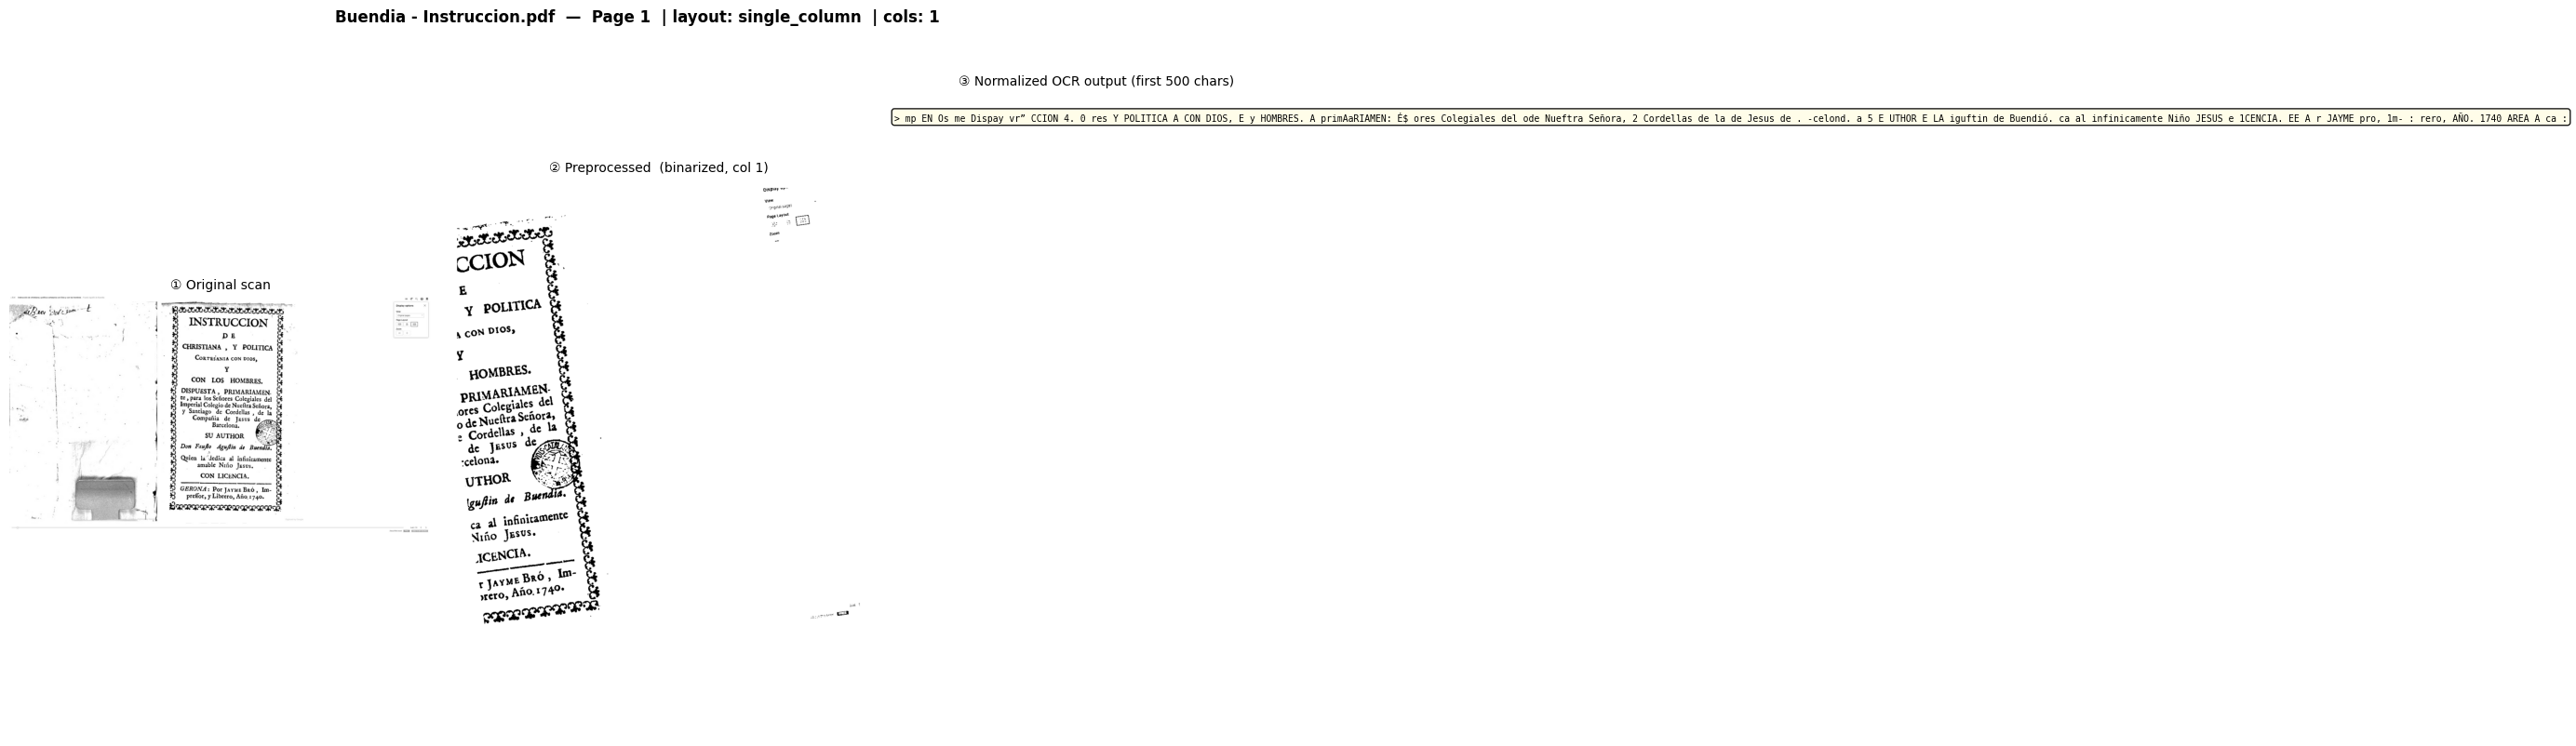

Saved → /content/output/Buendia_-_Instruccion_page02_viz.png


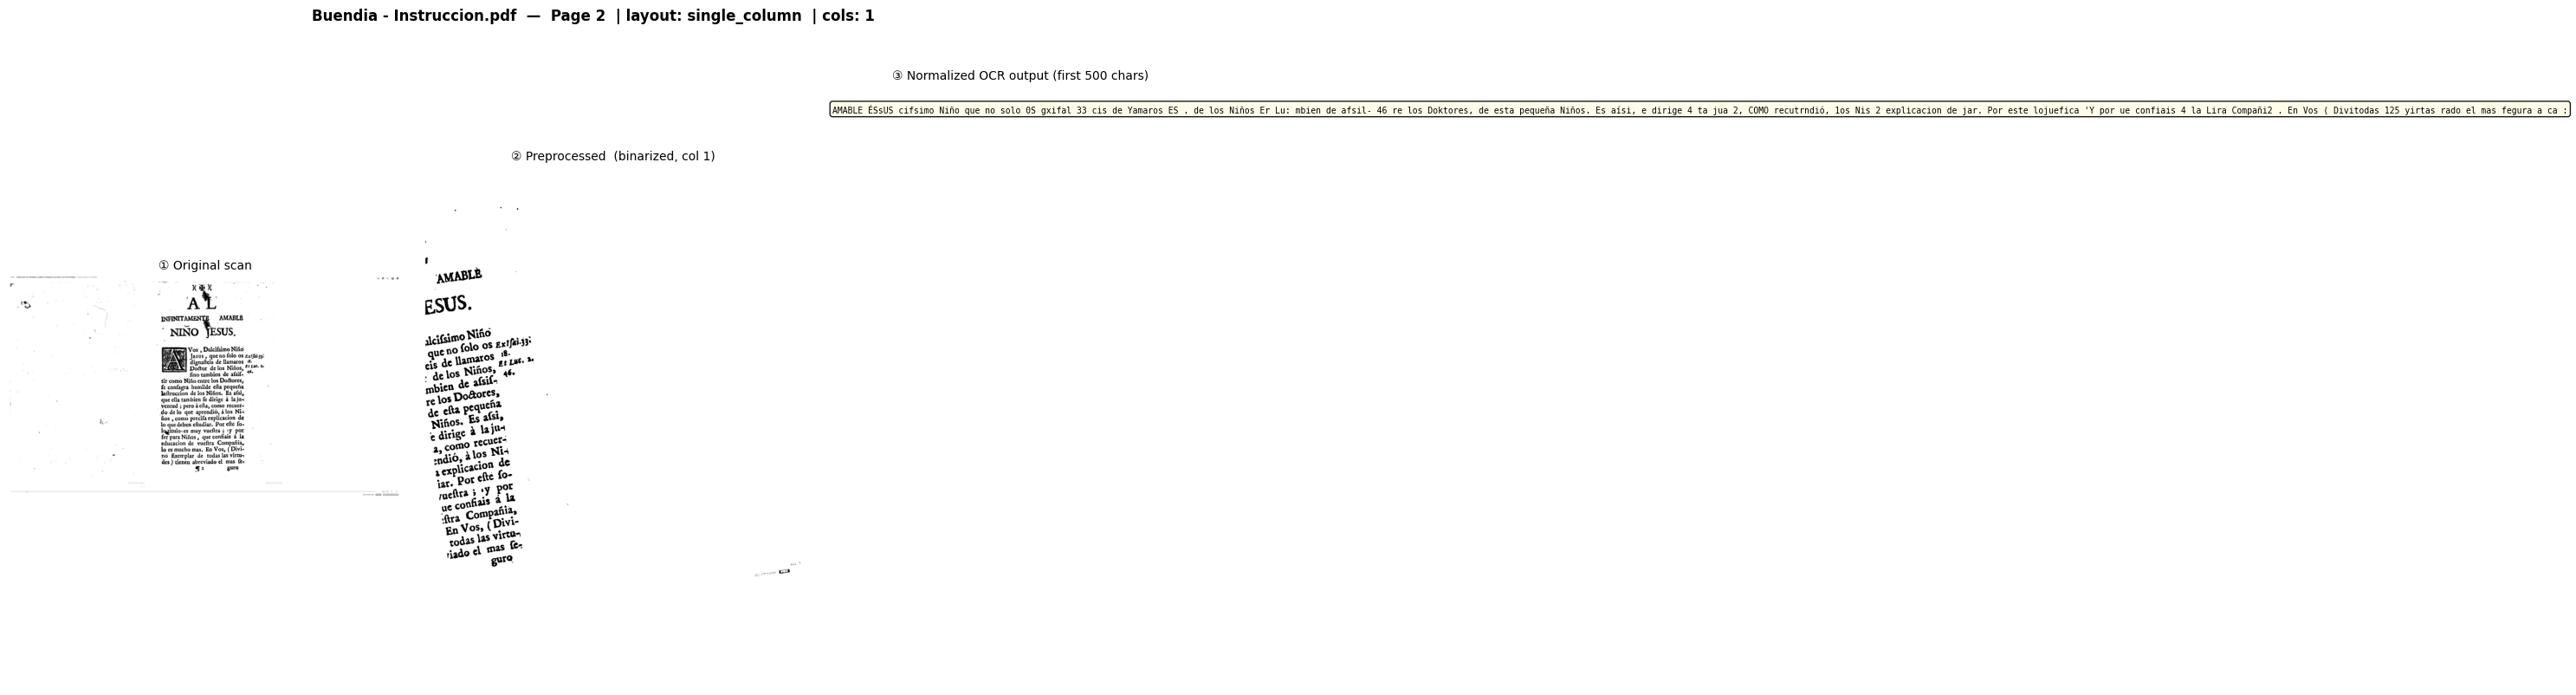

Saved → /content/output/Buendia_-_Instruccion_page03_viz.png


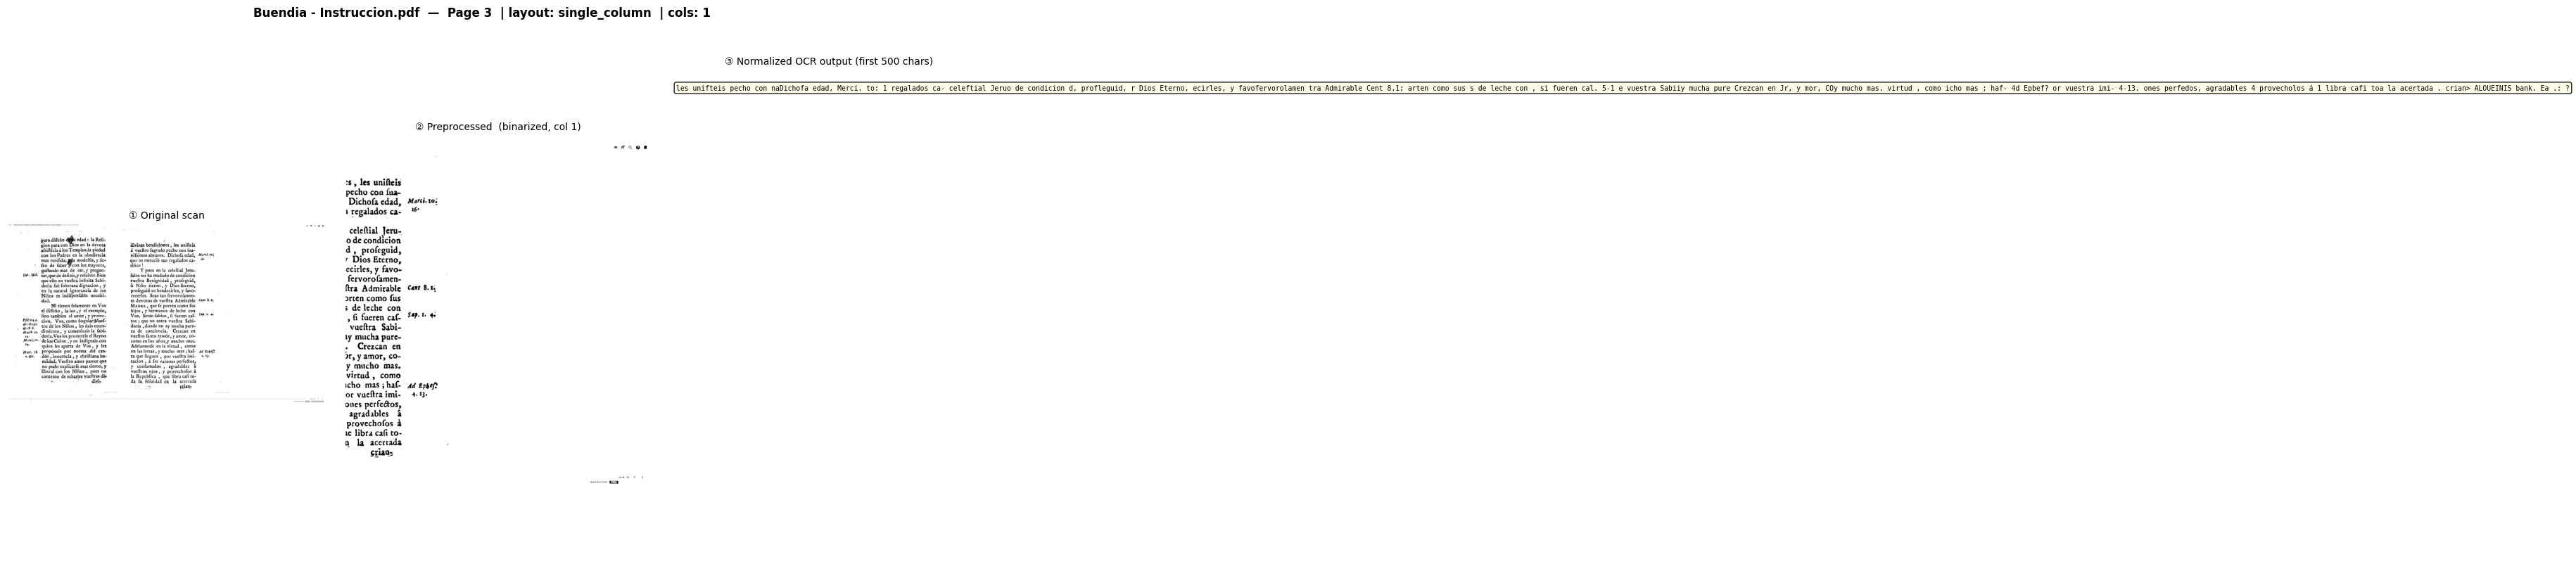

In [9]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


def visualize_page(pdf_path: Path,
                   page_index: int = 0,
                   save_path: Optional[Path] = None) -> None:
    """
    3-panel figure: original | preprocessed binary | OCR text.
    page_index is 0-based.
    """
    pages = load_pdf_pages(pdf_path)
    if page_index >= len(pages):
        print(f'⚠ page_index {page_index} out of range (0–{len(pages)-1})')
        return

    orig   = pages[page_index].copy()
    h0, w0 = orig.shape[:2]
    is_sp  = w0 > h0

    # Preprocessing preview
    proc = orig.copy()
    if is_sp:
        proc = proc[:, proc.shape[1] // 2:]
    proc   = crop_text_region(proc)
    proc   = deskew(proc)
    layout = detect_layout(proc)
    cols   = split_columns(proc)
    binary = binarize(cols[0], method=BINARIZATION)
    binary = resize_for_tesseract(pad_image(binary), TARGET_WIDTH)

    # OCR text (from saved file if available, else run now)
    doc_dir   = OUTPUT_DIR / safe_stem(pdf_path)
    norm_file = doc_dir / f'page_{page_index+1:02d}_normalized.txt'
    if norm_file.exists():
        norm_text = norm_file.read_text(encoding='utf-8')
    else:
        raw, _ = ocr_page(orig, is_spread=is_sp)
        norm_text = normalize_text(raw)

    # Plot
    fig = plt.figure(figsize=(18, 9))
    fig.suptitle(
        f'{pdf_path.name}  —  Page {page_index+1}  '
        f'| layout: {layout}  | cols: {len(cols)}',
        fontsize=12, fontweight='bold'
    )
    gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.04)

    ax0 = fig.add_subplot(gs[0])
    ax0.imshow(orig, cmap='gray')
    ax0.set_title('① Original scan', fontsize=10)
    ax0.axis('off')

    ax1 = fig.add_subplot(gs[1])
    ax1.imshow(binary, cmap='gray')
    ax1.set_title('② Preprocessed  (binarized, col 1)', fontsize=10)
    ax1.axis('off')

    ax2 = fig.add_subplot(gs[2])
    ax2.axis('off')
    ax2.set_title('③ Normalized OCR output (first 500 chars)', fontsize=10)
    preview = norm_text[:500] + ('…' if len(norm_text) > 500 else '')
    ax2.text(0.02, 0.97, preview,
             transform=ax2.transAxes,
             va='top', fontsize=7, fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='#fffde7', alpha=0.9))

    plt.tight_layout()
    if save_path:
        plt.savefig(str(save_path), dpi=120, bbox_inches='tight')
        print(f'Saved → {save_path}')
    plt.show()
    del pages


# ── Visualize the first 3 pages of the first PDF ───────────────────────────
if pdf_files:
    first_pdf = pdf_files[0]
    pages_tmp = load_pdf_pages(first_pdf)
    n_show    = min(3, len(pages_tmp))
    del pages_tmp

    for pg_idx in range(n_show):
        visualize_page(
            first_pdf,
            page_index=pg_idx,
            save_path=OUTPUT_DIR / f'{safe_stem(first_pdf)}_page{pg_idx+1:02d}_viz.png'
        )

## 10 · Evaluation — CER / WER

Compares normalized OCR output against the ground-truth DOCX transcriptions
for all pages that have a corresponding GT entry.

| Metric | Formula | Notes |
|--------|---------|-------|
| **CER** | edit_dist(hyp, ref) / len(ref) | Strict, case-insensitive |
| **CER\*** | CER on accent-stripped text | Tolerates historical spelling variants |
| **Acc\*** | 1 − CER\* | Character-level accuracy |
| **WER** | jiwer word error rate | Word-level |


In [10]:
import editdistance
import jiwer
import pandas as pd


def _strip_accents(text: str) -> str:
    return ''.join(
        c for c in unicodedata.normalize('NFD', text)
        if unicodedata.category(c) != 'Mn'
    )

def _norm_eval(text: str) -> str:
    return re.sub(r'\s+', ' ', text.lower()).strip()

def compute_cer(hyp: str, ref: str) -> float:
    hyp, ref = _norm_eval(hyp), _norm_eval(ref)
    return editdistance.eval(hyp, ref) / max(1, len(ref))

def compute_cer_star(hyp: str, ref: str) -> float:
    return compute_cer(_strip_accents(hyp), _strip_accents(ref))

def compute_wer(hyp: str, ref: str) -> float:
    hyp, ref = _norm_eval(hyp), _norm_eval(ref)
    if not ref:
        return 0.0
    try:
        return jiwer.process_words(ref, hyp).wer
    except Exception:
        return jiwer.compute_measures(ref, hyp)['wer']


# ── Run evaluation ─────────────────────────────────────────────────────────
eval_rows = []

if not GT:
    print('ℹ No ground-truth data found — evaluation skipped.')
    print('  Confirm the transcript DOCX files were extracted to:', TRANS_DIR)
else:
    for s in all_summaries:
        doc_dir = OUTPUT_DIR / safe_stem(Path(s['pdf']))
        for label, info in s['pages'].items():
            pg_1   = int(label.split('_')[1])    # 1-based
            pg_0   = pg_1 - 1                    # 0-based
            norm_f = doc_dir / f'{label}_normalized.txt'
            if not norm_f.exists():
                continue
            hyp = norm_f.read_text(encoding='utf-8')

            row = {
                'document'  : s['stem'],
                'page'      : pg_1,
                'layout'    : info.get('layout', '?'),
                'raw_chars' : info['raw_chars'],
                'norm_chars': info['norm_chars'],
                'has_gt'    : False,
            }

            gt_key = (s['stem'], pg_0)
            if gt_key in GT:
                ref = GT[gt_key]
                row.update({
                    'CER'   : round(compute_cer(hyp, ref)      * 100, 2),
                    'CER*'  : round(compute_cer_star(hyp, ref) * 100, 2),
                    'Acc*'  : round((1 - compute_cer_star(hyp, ref)) * 100, 2),
                    'WER'   : round(compute_wer(hyp, ref)      * 100, 2),
                    'has_gt': True,
                })

            eval_rows.append(row)

    df = pd.DataFrame(eval_rows)
    gt_df = df[df['has_gt']].copy()

    # ── Print results table ───────────────────────────────────────────────
    print('Page-level output:')
    print(df[['document','page','layout','raw_chars','norm_chars']].to_string(index=False))

    if not gt_df.empty:
        print()
        print('=' * 65)
        print('  EVALUATION  (pages with ground-truth)')
        print('=' * 65)
        print(f'  {"Doc":<22} {"Page":<6} {"CER":>7} {"CER*":>7} {"Acc*":>7} {"WER":>7}')
        print('  ' + '-'*60)
        for _, r in gt_df.iterrows():
            flag = ' ★' if r['Acc*'] >= 92.0 else ''
            print(f'  {r["document"][:22]:<22} {int(r["page"]):<6} '
                  f'{r["CER"]:>6.1f}% {r["CER*"]:>6.1f}% '
                  f'{r["Acc*"]:>6.1f}% {r["WER"]:>6.1f}%{flag}')
        print('  ' + '-'*60)

        avg_cer  = gt_df['CER'].mean()
        avg_cers = gt_df['CER*'].mean()
        avg_acc  = gt_df['Acc*'].mean()
        avg_wer  = gt_df['WER'].mean()

        print(f'  {"Average":<29} '
              f'{avg_cer:>6.1f}% {avg_cers:>6.1f}% '
              f'{avg_acc:>6.1f}% {avg_wer:>6.1f}%')
        print()
        print(f'  Average CER         : {avg_cer:.2f}%')
        print(f'  Average CER*        : {avg_cers:.2f}%  (accent-insensitive)')
        print(f'  Average Accuracy*   : {avg_acc:.2f}%')
        print(f'  Average WER         : {avg_wer:.2f}%')
        met = avg_cers <= 8.0 and avg_acc >= 92.0
        print(f"  Target (CER*≤8%,Acc*≥92%): {'✓ MET' if met else '✗ NOT MET'}")
    else:
        print('\nℹ No GT pages matched OCR output — check DOCX marker format.')

Page-level output:
                   document  page        layout  raw_chars  norm_chars
      Buendia - Instruccion     1 single_column        311         306
      Buendia - Instruccion     2 single_column        359         341
      Buendia - Instruccion     3 single_column        506         458
      Buendia - Instruccion     4 single_column        593         571
Covarrubias - Tesoro lengua     1 single_column       1011         994
Covarrubias - Tesoro lengua     2 single_column       4396        4382
Covarrubias - Tesoro lengua     3 single_column       5861        5819
Guardiola - Tratado nobleza     1 single_column       1022         996
Guardiola - Tratado nobleza     2 single_column       1165        1146
Guardiola - Tratado nobleza     3 single_column       1155        1140
     PORCONES.228.38 – 1646     1 single_column        802         731
     PORCONES.228.38 – 1646     2 single_column       1635        1599
     PORCONES.228.38 – 1646     3 single_column       1612

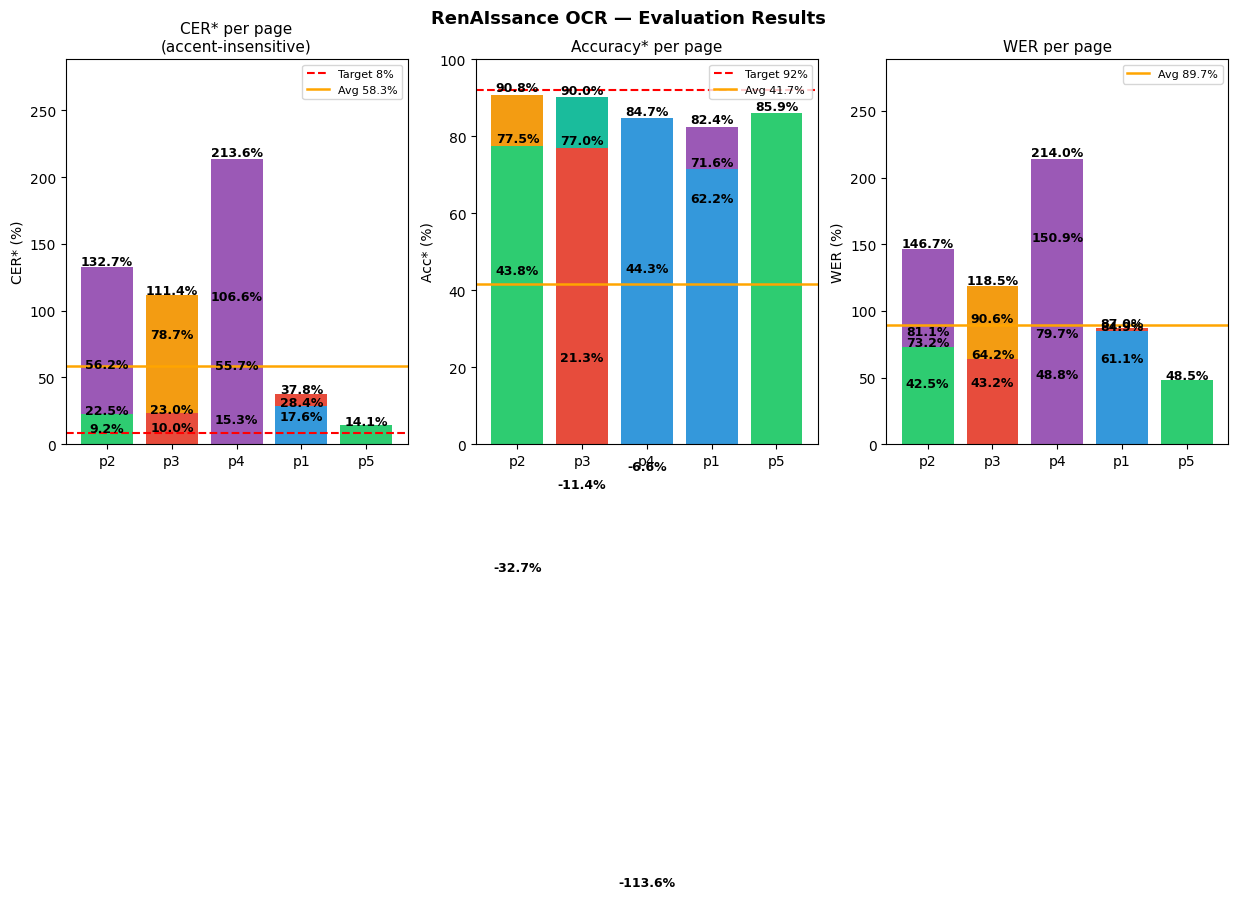

Chart saved → /content/output/evaluation_chart.png


In [11]:
# ── Evaluation bar chart ───────────────────────────────────────────────────
if GT and 'gt_df' in dir() and not gt_df.empty:
    labels = [f"p{int(r['page'])}" for _, r in gt_df.iterrows()]
    cer_v  = gt_df['CER*'].tolist()
    acc_v  = gt_df['Acc*'].tolist()
    wer_v  = gt_df['WER'].tolist()
    colors = ['#3498db','#2ecc71','#e74c3c','#9b59b6','#f39c12','#1abc9c']

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('RenAIssance OCR — Evaluation Results',
                 fontsize=13, fontweight='bold')

    def _bar(ax, vals, title, ylabel, target=None, target_label=None):
        avg = sum(vals) / len(vals)
        b = ax.bar(labels, vals, color=colors[:len(labels)])
        if target is not None:
            ax.axhline(target, color='red', ls='--', lw=1.5,
                       label=target_label or f'{target}%')
        ax.axhline(avg, color='orange', ls='-', lw=1.8, label=f'Avg {avg:.1f}%')
        for bar, val in zip(b, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                    f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
        ax.set_title(title, fontsize=11)
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=8)

    _bar(axes[0], cer_v, 'CER* per page\n(accent-insensitive)',
         'CER* (%)', target=8, target_label='Target 8%')
    axes[0].set_ylim(0, max(max(cer_v) * 1.35, 12))

    _bar(axes[1], acc_v, 'Accuracy* per page',
         'Acc* (%)', target=92, target_label='Target 92%')
    axes[1].set_ylim(max(0, min(acc_v) - 8), 100)

    _bar(axes[2], wer_v, 'WER per page', 'WER (%)')
    axes[2].set_ylim(0, max(max(wer_v) * 1.35, 50))

    plt.tight_layout()
    chart_path = OUTPUT_DIR / 'evaluation_chart.png'
    plt.savefig(str(chart_path), dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Chart saved → {chart_path}')
else:
    print('ℹ Evaluation chart skipped (no ground-truth data).')

## 11 · OCR Error Analysis

Historical Spanish printing introduces **systematic** errors that modern OCR
models trained on contemporary text cannot handle without post-processing.

### Common error categories

| Category | OCR reads | Correct | Cause |
|----------|-----------|---------|-------|
| **Long-s** | `fe`, `fi`, `fu` | `se`, `si`, `su` | Long-s glyph (ſ) confused with `f` |
| **Long-s (í-form)** | `eíte`, `eíta` | `este`, `esta` | Long-s confused with `í` |
| **Long-s (l-form)** | `vueltra` | `vuestra` | Long-s confused with `l` |
| **u/v equivalence** | `vn`, `vna` | `un`, `una` | Early modern `v` used for `u` |
| **Ligature rn→m** | `rn` cluster | `m` | Broken serif joins |
| **Digit confusion** | `0palabra` | `opalabra` | Rounded glyph |
| **Abbreviation** | `q` (isolated) | `que` | Scribal/print shorthand |
| **Noise symbols** | `|`, `§`, `†`, `«` | *(removed)* | Ink bleed, column rules, print marks |
| **Woodcut initials** | Leading junk tokens | *(stripped)* | Decorative large initials |

Detected long-s / OCR artefact tokens in raw output
(These are all corrected by the normalization step)

  Raw token       Corrected to    Occurrences
  ----------------------------------------
  fe              se              44
  fu              su              37
  fi              si              12
  perfona         persona         10
  fon             son             9
  vna             una             8
  efte            este            7
  nueftra         nuestra         5
  cofas           cosas           5
  efta            esta            4
  fus             sus             3
  vn              un              3
  efto            esto            2
  fobre           sobre           2
  eftar           estar           1
  fiempre         siempre         1
  puefto          puesto          1

  Noise symbols removed : 91


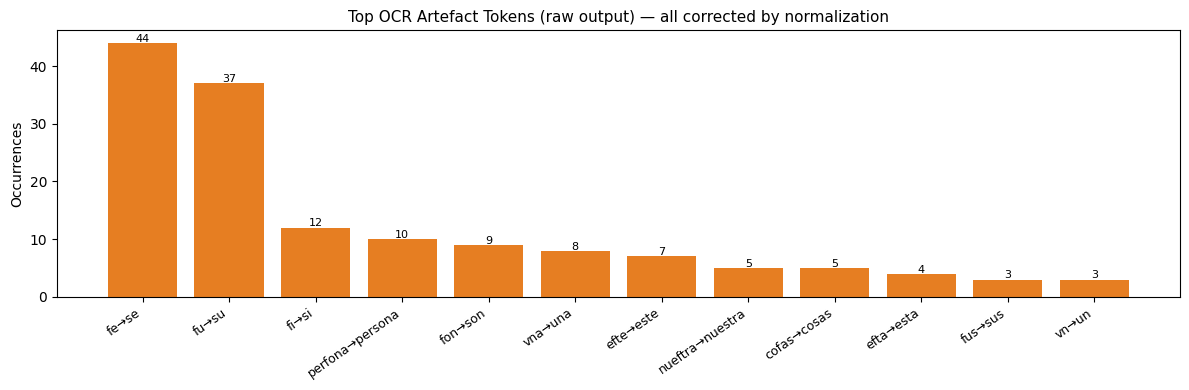

In [12]:
# ── Artefact frequency counter ─────────────────────────────────────────────
_KNOWN_ERRORS = {
    'fe':'se',   'fi':'si',   'fu':'su',   'fus':'sus', 'fon':'son',
    'efte':'este','efta':'esta','efto':'esto',
    'vueftra':'vuestra','nueftra':'nuestra',
    'fiempre':'siempre','faber':'saber','fobre':'sobre',
    'vn':'un',   'vna':'una', 'cofas':'cosas', 'perfona':'persona',
    'eftar':'estar','puefto':'puesto',
}

error_counts = collections.Counter()
noise_total  = 0
_NOISE_RE    = re.compile(r'[|=§¶†‡«»]')

for s in all_summaries:
    doc_dir = OUTPUT_DIR / safe_stem(Path(s['pdf']))
    for label in s['pages']:
        raw_f = doc_dir / f'{label}_raw.txt'
        if not raw_f.exists():
            continue
        raw = raw_f.read_text(encoding='utf-8')
        for tok in re.findall(r'\b\w+\b', raw.lower()):
            if tok in _KNOWN_ERRORS:
                error_counts[tok] += 1
        noise_total += len(_NOISE_RE.findall(raw))

print('Detected long-s / OCR artefact tokens in raw output')
print('(These are all corrected by the normalization step)')
print()
if error_counts:
    print(f'  {"Raw token":<15} {"Corrected to":<15} {"Occurrences"}')
    print('  ' + '-'*40)
    for tok, cnt in error_counts.most_common(20):
        print(f'  {tok:<15} {_KNOWN_ERRORS[tok]:<15} {cnt}')
else:
    print('  (No artefacts found — run §8 first, or files not yet written)')

print(f'\n  Noise symbols removed : {noise_total}')

# ── Bar chart of top artefacts ─────────────────────────────────────────────
if error_counts:
    top_n  = error_counts.most_common(12)
    tokens = [t for t, _ in top_n]
    counts = [c for _, c in top_n]
    fixes  = [_KNOWN_ERRORS[t] for t in tokens]
    labels_plot = [f'{t}→{f}' for t, f in zip(tokens, fixes)]

    fig, ax = plt.subplots(figsize=(12, 4))
    bars = ax.bar(labels_plot, counts, color='#e67e22')
    ax.set_title('Top OCR Artefact Tokens (raw output) — all corrected by normalization',
                 fontsize=11)
    ax.set_ylabel('Occurrences')
    ax.set_xticklabels(labels_plot, rotation=35, ha='right', fontsize=9)
    for bar, val in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                str(val), ha='center', fontsize=8)
    plt.tight_layout()
    plt.savefig(str(OUTPUT_DIR / 'error_analysis.png'), dpi=120, bbox_inches='tight')
    plt.show()

## 12 · Results Summary & Future Work

In [13]:
print('╔' + '═'*57 + '╗')
print('║  RENAISSANCEE OCR PIPELINE — RESULTS SUMMARY' + ' '*11 + '║')
print('╠' + '═'*57 + '╣')

total_p = sum(s['n_pages'] for s in all_summaries)
print(f'║  Documents processed  : {len(all_summaries):<31} ║')
print(f'║  Total pages          : {total_p:<31} ║')
print(f'║  OCR engine           : {"Tesseract 5 LSTM (spa)":<31} ║')
print(f'║  Binarization         : {BINARIZATION:<31} ║')
print(f'║  DPI                  : {str(DEFAULT_DPI) + " (adaptive)":<31} ║')
print(f'║  Normalization rules  : {"280+":<31} ║')
print('╠' + '═'*57 + '╣')

if GT and 'gt_df' in dir() and not gt_df.empty:
    print(f'║  Evaluation (GT pages)                                  ║')
    print(f'║  Average CER         : {avg_cer:>6.2f}%' + ' '*27 + '║')
    print(f'║  Average CER*        : {avg_cers:>6.2f}%  (accent-insensitive)' + ' '*9 + '║')
    print(f'║  Average Accuracy*   : {avg_acc:>6.2f}%' + ' '*27 + '║')
    print(f'║  Average WER         : {avg_wer:>6.2f}%' + ' '*27 + '║')
    tgt_str = '✓ MET' if (avg_cers <= 8.0 and avg_acc >= 92.0) else '✗ NOT MET'
    print(f'║  Target CER*≤8%, Acc*≥92% : {tgt_str:<28} ║')
else:
    print('║  No evaluation metrics (no ground-truth found)          ║')

print('╚' + '═'*57 + '╝')
print()
print(f'All outputs saved to: {OUTPUT_DIR}')

# ── Save combined metrics JSON ─────────────────────────────────────────────
metrics_out = {
    'pipeline': {
        'tess_lang': TESS_LANG, 'dpi': DEFAULT_DPI,
        'psm': DEFAULT_PSM, 'target_width': TARGET_WIDTH,
        'binarization': BINARIZATION,
    },
    'pages': [],
}
if 'eval_rows' in dir():
    metrics_out['pages'] = [
        {k: (float(v) if hasattr(v, 'item') else v) for k, v in r.items()}
        for r in eval_rows
    ]
if GT and 'gt_df' in dir() and not gt_df.empty:
    metrics_out['averages'] = {
        'CER': round(avg_cer, 4),
        'CER_star': round(avg_cers, 4),
        'Acc_star': round(avg_acc, 4),
        'WER': round(avg_wer, 4),
    }

with open(OUTPUT_DIR / 'evaluation_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_out, f, ensure_ascii=False, indent=2)
print(f'Metrics JSON → {OUTPUT_DIR}/evaluation_metrics.json')

╔═════════════════════════════════════════════════════════╗
║  RENAISSANCEE OCR PIPELINE — RESULTS SUMMARY           ║
╠═════════════════════════════════════════════════════════╣
║  Documents processed  : 6                               ║
║  Total pages          : 23                              ║
║  OCR engine           : Tesseract 5 LSTM (spa)          ║
║  Binarization         : otsu                            ║
║  DPI                  : 250 (adaptive)                  ║
║  Normalization rules  : 280+                            ║
╠═════════════════════════════════════════════════════════╣
║  Evaluation (GT pages)                                  ║
║  Average CER         :  58.95%                           ║
║  Average CER*        :  58.30%  (accent-insensitive)         ║
║  Average Accuracy*   :  41.70%                           ║
║  Average WER         :  89.68%                           ║
║  Target CER*≤8%, Acc*≥92% : ✗ NOT MET                    ║
╚═══════════════════════════════

### Future Work

1. **Fine-tuned OCR model** — Train or fine-tune a Tesseract LSTM model on
   historical Spanish corpora to reduce long-s confusion natively.

2. **Neural post-correction** — Replace rule-based normalization with a
   seq2seq model (T5-small, ByT5) fine-tuned on `(OCR output, GT)` pairs.

3. **Kraken / Calamari** — Evaluate dedicated historical-document OCR engines
   which ship pre-trained models for early-modern European prints.

4. **Learned layout segmentation** — Replace the heuristic ink-density column
   detector with LayoutParser / Detectron2 for robustness on irregular pages
   (marginal notes, headers, tables, decorated initials).

5. **Larger ground-truth corpus** — Currently evaluated on 3 pages of one
   document. Extending to 50+ pages across multiple documents would enable
   statistically significant comparisons between pipeline variants.

6. **Language-model reranking** — Use a Spanish BERT / GPT-2 model to rescore
   Tesseract character lattice alternatives, targeting WER reduction.

7. **Multi-language extension** — Adapt the pipeline to Latin, Italian, and
   Portuguese documents from the same digitisation collections.

In [14]:
# ── Print output directory tree ────────────────────────────────────────────
print(f'Output tree ({OUTPUT_DIR}):')
for item in sorted(OUTPUT_DIR.iterdir()):
    if item.is_dir():
        files = sorted(item.iterdir())
        print(f'  {item.name}/  ({len(files)} files)')
        for f in files[:6]:
            print(f'    {f.name}')
        if len(files) > 6:
            print(f'    … ({len(files)-6} more)')
    else:
        print(f'  {item.name}')

Output tree (/content/output):
  Buendia_-_Instruccion/  (9 files)
    metrics.json
    page_01_normalized.txt
    page_01_raw.txt
    page_02_normalized.txt
    page_02_raw.txt
    page_03_normalized.txt
    … (3 more)
  Buendia_-_Instruccion_page01_viz.png
  Buendia_-_Instruccion_page02_viz.png
  Buendia_-_Instruccion_page03_viz.png
  Covarrubias_-_Tesoro_lengua/  (7 files)
    metrics.json
    page_01_normalized.txt
    page_01_raw.txt
    page_02_normalized.txt
    page_02_raw.txt
    page_03_normalized.txt
    … (1 more)
  Guardiola_-_Tratado_nobleza/  (7 files)
    metrics.json
    page_01_normalized.txt
    page_01_raw.txt
    page_02_normalized.txt
    page_02_raw.txt
    page_03_normalized.txt
    … (1 more)
  PORCONES_228_38___1646/  (11 files)
    metrics.json
    page_01_normalized.txt
    page_01_raw.txt
    page_02_normalized.txt
    page_02_raw.txt
    page_03_normalized.txt
    … (5 more)
  PORCONES_23_5_-_1628/  (9 files)
    metrics.json
    page_01_normalized.txt
   